In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import networkx as nx

def load_assets_to_graph(graph, assets_filepath):
    """
    Loads asset data from a CSV file into a NetworkX DiGraph.

    Each row in the CSV is added as a node. The 'Asset_ID' column is used
    as the node identifier. Node attributes 'criticality_score' and 'status'
    are also added.

    Args:
        graph (nx.DiGraph): The NetworkX DiGraph object to add nodes to.
        assets_filepath (str): The file path for the assets CSV data.

    Returns:
        nx.DiGraph: The graph with the new nodes added.
    """
    try:
        # Read the asset data from the CSV file into a pandas DataFrame
        assets_df = pd.read_csv(assets_filepath)
        print(f"Successfully loaded {assets_filepath}")

        # Iterate over each row in the DataFrame
        for index, row in assets_df.iterrows():
            asset_id = row['Asset_ID']
            criticality_score = row['Criticality Score']

            # Add a node to the graph for each asset
            # The node ID is the Asset_ID from the CSV
            # Attributes for criticality score and a default status are added
            graph.add_node(
                asset_id,
                criticality_score=float(criticality_score),
                status="working"
            )
        
        print(f"Added {graph.number_of_nodes()} nodes to the graph.")
        return graph

    except FileNotFoundError:
        print(f"Error: The file '{assets_filepath}' was not found.")
        return None
    except KeyError as e:
        print(f"Error: A required column is missing from the CSV: {e}")
        return None


def add_dependencies_to_graph(graph, dependencies_filepath):
    """
    Adds weighted, directed edges to a graph based on a dependency CSV file.

    The function reads a CSV file to establish connections (edges) between
    existing nodes in the graph.

    Args:
        graph (nx.DiGraph): The NetworkX DiGraph object to add edges to.
        dependencies_filepath (str): The file path for the dependencies CSV.

    Returns:
        nx.DiGraph: The graph with the new edges added.
    """
    if graph is None:
        print("Error: The graph object is invalid. Cannot add dependencies.")
        return None
        
    try:
        # Read the dependency data from the CSV file
        dependencies_df = pd.read_csv(dependencies_filepath)
        print(f"\nSuccessfully loaded {dependencies_filepath}")

        # Iterate over each row in the DataFrame to create edges
        for index, row in dependencies_df.iterrows():
            from_asset = row['from_asset']
            to_asset = row['to_asset']
            dependency_score = row['dependency_score']

            # Check if both nodes exist in the graph before adding an edge
            if graph.has_node(from_asset) and graph.has_node(to_asset):
                # Add a directed edge from 'from_asset' to 'to_asset'
                # The 'weight' of the edge is the dependency_score
                graph.add_edge(
                    from_asset,
                    to_asset,
                    weight=float(dependency_score)
                )
            else:
                # Print a warning if a node mentioned in the dependency file
                # does not exist in the graph.
                if not graph.has_node(from_asset):
                    print(f"Warning: Node '{from_asset}' not found in graph. Skipping edge.")
                if not graph.has_node(to_asset):
                    print(f"Warning: Node '{to_asset}' not found in graph. Skipping edge.")

        print(f"Added edges. The graph now has {graph.number_of_edges()} edges.")
        return graph

    except FileNotFoundError:
        print(f"Error: The file '{dependencies_filepath}' was not found.")
        return None
    except KeyError as e:
        print(f"Error: A required column is missing from the CSV: {e}")
        return None

In [12]:
def filter_graph_by_criticality(graph, threshold):
    """
    Filters a graph to include only nodes with a criticality score
    above or equal to a given threshold.

    Args:
        graph (nx.DiGraph): The input graph.
        threshold (float): The minimum criticality score for a node to be included.

    Returns:
        nx.DiGraph: A new graph containing only the filtered nodes and their edges.
    """
    if graph is None:
        print("Error: The graph object is invalid. Cannot filter.")
        return None

    # Identify nodes that meet the criticality score threshold
    nodes_to_keep = [
        node for node, data in graph.nodes(data=True)
        if data.get('criticality_score', 0) >= threshold
    ]
    
    # Create a new graph containing only the selected nodes and the edges between them
    filtered_graph = graph.subgraph(nodes_to_keep).copy()
    
    print(f"\nFiltered graph by criticality score >= {threshold}.")
    return filtered_graph

In [ ]:
CRITICALITY_THRESHOLD = 3.0
critical_G = filter_graph_by_criticality(G, CRITICALITY_THRESHOLD)

In [3]:
# if __name__ == '__main__':
# Define file paths
ASSETS_FILE = '01-failure-of-national-electricity-transmission-network.csv'
DEPENDENCIES_FILE = '01_dependency_mapping.csv'

# 1. Initialize a new directed graph
G = nx.DiGraph()

# 2. Load the assets as nodes into the graph
G = load_assets_to_graph(G, ASSETS_FILE)

# 3. Load the dependencies as edges into the graph
G = add_dependencies_to_graph(G, DEPENDENCIES_FILE)



Successfully loaded 01-failure-of-national-electricity-transmission-network.csv
Added 95 nodes to the graph.

Successfully loaded 01_dependency_mapping.csv
Added edges. The graph now has 72 edges.


In [4]:
# 4. Verification (if the graph was created successfully)
if G is not None:
    print("\n--- Graph Verification ---")
    print(f"Total nodes in the final graph: {G.number_of_nodes()}")
    print(f"Total edges in the final graph: {G.number_of_edges()}")





--- Graph Verification ---
Total nodes in the final graph: 95
Total edges in the final graph: 72


In [5]:
# Display a sample node and its data
if 'PGS07' in G:
    print("\nSample Node Data (PGS07):")
    print(G.nodes['PGS07'])




Sample Node Data (PGS07):
{'criticality_score': 3.0, 'status': 'working'}


In [6]:
# Display a sample edge and its data
if G.has_edge('PGS07', 'BSC04'):
    print("\nSample Edge Data (PGS07 -> BSC04):")
    print(G.edges[('PGS07', 'BSC04')])


Sample Edge Data (PGS07 -> BSC04):
{'weight': 2.0}


In [9]:
# 4. Function to simulate failure propagation
def simulate_failure(G, failed_node, threshold=0.5):
    print(f"Failing: {failed_node}")
    G.nodes[failed_node]["status"] = "failed"
    
    # Use BFS to propagate failure
    for neighbor in nx.descendants(G, failed_node):
        path = nx.shortest_path(G, source=failed_node, target=neighbor)
        min_dependency = min(G.edges[path[i], path[i+1]]["weight"] for i in range(len(path)-1))
        
        if min_dependency >= threshold:
            print(f"Propagated failure to: {neighbor} (via dependency {min_dependency})")
            G.nodes[neighbor]["status"] = "failed"





In [10]:
# 5. Simulate failure of substation
simulate_failure(G, "PGS07", threshold=2)

Failing: PGS07
Propagated failure to: TEL09 (via dependency 3.0)
Propagated failure to: NH04 (via dependency 2.5)
Propagated failure to: TEL10 (via dependency 3.0)
Propagated failure to: BSC05 (via dependency 2.0)
Propagated failure to: TEL06 (via dependency 3.0)
Propagated failure to: FS07 (via dependency 2.0)
Propagated failure to: VH05 (via dependency 2.5)
Propagated failure to: NH02 (via dependency 2.5)
Propagated failure to: TRR03 (via dependency 2.5)
Propagated failure to: BSC04 (via dependency 2.0)
Propagated failure to: SCH07 (via dependency 2.5)
Propagated failure to: SCH03 (via dependency 2.5)
Propagated failure to: SCH09 (via dependency 2.5)
Propagated failure to: FS01 (via dependency 2.0)
Propagated failure to: TEL03 (via dependency 3.0)
Propagated failure to: WS01 (via dependency 3.0)
Propagated failure to: SCH05 (via dependency 2.5)
Propagated failure to: TEL11 (via dependency 3.0)
Propagated failure to: TEL04 (via dependency 3.0)


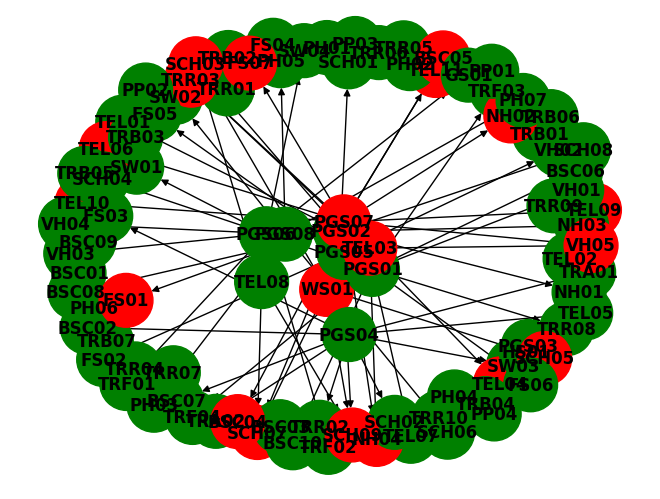

In [11]:
# 6. Visualize graph with failed nodes in red
colors = ["red" if G.nodes[n]["status"] == "failed" else "green" for n in G.nodes]
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=1500, font_weight="bold")
edge_labels = nx.get_edge_attributes(G, "dependency")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()